In [62]:
%matplotlib widget

import os
import sys
import glob
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import RectangleSelector

PROJECT_PATH = os.path.abspath(os.path.join("..", ".."))
PIPELINE_PATH = os.path.join(PROJECT_PATH, "pipeline")
DATA_DIRECTORY = os.path.join(PROJECT_PATH, "data")

if PIPELINE_PATH not in sys.path:
    sys.path.append(PIPELINE_PATH)
    
from utils.paths import ICOS_CITIES_LEVEL_1, PIPELINE_DATA_DIRECTORY
from utils.os_functions import ensure_data_dir

assert (os.path.exists(ICOS_CITIES_LEVEL_1))
assert (os.path.exists(PIPELINE_DATA_DIRECTORY))

In [34]:
def annotate_month(
    df: pl.DataFrame,
    flag: np.ndarray,
    year: int,
    month: int,
    time_col="#Datetime",
    value_col="co2",
    # --- wind mask config ---
    ws_col="ws",
    wd_col="wd",
    ws_max=2.0,
    wd_ranges=((330, 30),),   # wrap-around supported
    # --- behavior ---
    overlay_wind=True,        # show wind mask overlay
    auto_flag_wind=False,     # immediately set global flag=1 for wind-masked points
    shade_wind=False,         # shade contiguous time spans where wind_mask is True
):
    # ---- helpers ----
    def wd_in_ranges_np(wd_deg: np.ndarray, ranges):
        wd = np.mod(wd_deg, 360.0)
        out = np.zeros_like(wd, dtype=bool)
        for lo, hi in ranges:
            lo, hi = lo % 360.0, hi % 360.0
            if lo <= hi:
                out |= (wd >= lo) & (wd <= hi)
            else:
                out |= (wd >= lo) | (wd <= hi)
        return out

    def contiguous_true_spans(t_np, mask_np):
        mask_np = np.asarray(mask_np, dtype=bool)
        idx = np.flatnonzero(mask_np)
        if idx.size == 0:
            return []
        breaks = np.where(np.diff(idx) > 1)[0]
        starts = np.r_[idx[0], idx[breaks + 1]]
        ends   = np.r_[idx[breaks], idx[-1]]
        return [(t_np[s], t_np[e]) for s, e in zip(starts, ends)]

    # ---- subset month ----
    sub = (
        df.filter(
            (pl.col(time_col).dt.year() == year) &
            (pl.col(time_col).dt.month() == month)
        )
        .select(["row_id", time_col, value_col, ws_col, wd_col])
    )

    row_id  = sub["row_id"].to_numpy()
    time_np = sub[time_col].to_numpy()
    val_np  = sub[value_col].to_numpy()
    ws_np = sub[ws_col].to_numpy()
    wd_np = sub[wd_col].to_numpy()

    # Convert None/nulls -> np.nan, enforce float dtype
    ws_f = np.asarray(ws_np, dtype=float)
    wd_f = np.asarray(wd_np, dtype=float)

    # Wind mask: nulls become False automatically via np.isfinite
    wind_mask = (
        np.isfinite(ws_f) & (ws_f <= ws_max) &
        np.isfinite(wd_f) & wd_in_ranges_np(wd_f, wd_ranges)
    )

    # optionally auto-flag wind-masked points in the GLOBAL flag array
    if auto_flag_wind:
        flag[row_id[wind_mask]] = 1

    # ---- colors for manual flag (global flag) ----
    c = flag[row_id]

    fig, ax = plt.subplots(figsize=(12, 5))
    sc = ax.scatter(time_np, val_np, c=c, cmap="coolwarm", vmin=0, vmax=1, s=25)

    ax.set_title(f"Annotate {year}-{month:02d} (drag rectangle to flag)")
    ax.set_xlabel("Time")
    ax.set_ylabel(value_col)
    ax.set_xlim(time_np.min(), time_np.max())
    ax.set_ylim(val_np.min() - 0.1 * abs(val_np.min()), val_np.max() + 0.1 * abs(val_np.max()))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    # ---- optional wind overlay ----
    if overlay_wind:
        # draw a subtle marker overlay for wind-masked points
        ax.scatter(
            time_np[wind_mask],
            val_np[wind_mask],
            s=18,
            alpha=0.35,
            marker="o",
            linewidths=0,
        )

    if shade_wind:
        for t0s, t1s in contiguous_true_spans(time_np, wind_mask):
            ax.axvspan(t0s, t1s, alpha=0.15)

    # ---- rectangle selector -> manual flagging ----
    def on_select(eclick, erelease):
        x0, x1 = eclick.xdata, erelease.xdata
        y0, y1 = eclick.ydata, erelease.ydata
        if x0 is None or x1 is None or y0 is None or y1 is None:
            return

        t0 = np.datetime64(mdates.num2date(x0).replace(tzinfo=None), "us")
        t1 = np.datetime64(mdates.num2date(x1).replace(tzinfo=None), "us")
        tmin, tmax = sorted([t0, t1])
        ymin, ymax = sorted([y0, y1])

        mask = (time_np >= tmin) & (time_np <= tmax) & (val_np >= ymin) & (val_np <= ymax)

        # flag selected points in GLOBAL flag array
        flag[row_id[mask]] = 1

        # update scatter colors
        sc.set_array(flag[row_id])
        fig.canvas.draw_idle()

    rect = RectangleSelector(ax, on_select, useblit=False, button=[1], interactive=True)
    fig._rect_selector = rect  # keep alive

    plt.show()
    return fig

In [30]:
sites_lookup = {}
# load csv files
L1_filenames = glob.glob(os.path.join(ICOS_CITIES_LEVEL_1, '*.csv'))

for path in L1_filenames:  
    site = os.path.basename(path).split('_')[0]
    # add to dict
    sites_lookup[site] = path

# print available keys
print(sites_lookup.keys())

dict_keys(['BALR', 'HARR', 'RDIR', 'MAIR', 'PASR', 'GROR', 'BOGR', 'FELR', 'BLUT', 'TAUR', 'DLRR', 'NPLR', 'SENR', 'SCHR', 'SWMR', 'MAIR2', 'TUMR', 'FINR'])


In [53]:
# Manually select site to work on
site = 'TUMR'

df = pl.read_csv(sites_lookup[site], skip_rows=44, has_header=True, separator=';', try_parse_dates=True)

# Ensure it's Polars Datetime (us) and add stable row id
df_site = df.with_row_index("row_id").with_columns(pl.col("#Datetime").cast(pl.Datetime("us"))).filter(pl.col("Flag") == "U")

# Global flags for the FULL df (persist across months)
flag = np.zeros(df.height, dtype=np.int8)

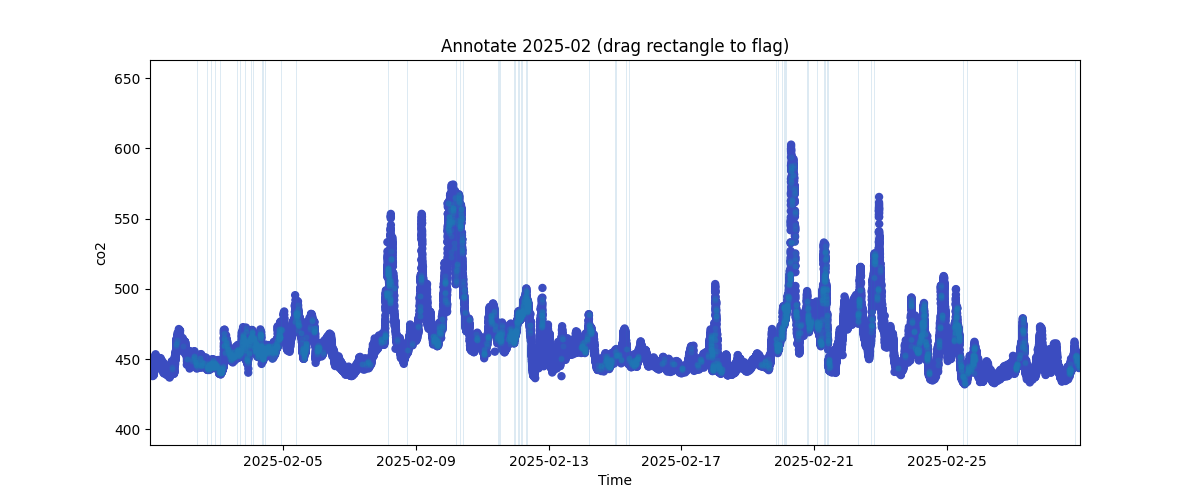

In [54]:
fig = annotate_month(
    df_site, flag,
    year=2025, month=2,
    ws_max=2,
    wd_ranges=((330, 30), (120, 160)),
    overlay_wind=True,
    auto_flag_wind=False,   # set True if you want those auto-flagged
    shade_wind=True
)

In [58]:
# Closes figure to free up memory
plt.close(fig)
# Add Manual_Flag column to original df
df_flagged = df.with_columns(pl.Series("Manual_Flag", flag))

# Percentage of flagged points
print("Percentage of flagged points:", 100 * df_flagged.get_column("Manual_Flag").sum() / df_flagged.height, "%")
df_flagged.filter(pl.col("Manual_Flag") != 0).tail()

Percentage of flagged points: 1.9045316811807003 %


#Datetime,Year,Month,Day,Hour,Minute,Second,DecimalDate,co2,h2o,pressure,sensor_temperature,ws,wd,Flag,Manual_Flag
datetime[μs],i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,str,i8
2025-02-18 01:51:30,2025,2,18,1,51,30,2025.131359,443.86,0.51,958.64,27.9,"""2.2""","""46.2""","""U""",1
2025-02-18 01:52:30,2025,2,18,1,52,30,2025.131361,444.11,0.5,958.64,27.9,"""2.2""","""46.2""","""U""",1
2025-02-18 01:53:30,2025,2,18,1,53,30,2025.131363,443.17,0.5,958.62,27.9,"""1.7""","""34.2""","""U""",1
2025-02-18 01:54:30,2025,2,18,1,54,30,2025.131365,444.47,0.5,958.62,27.9,"""1.7""","""34.2""","""U""",1
2025-02-18 01:55:30,2025,2,18,1,55,30,2025.131367,443.58,0.5,958.65,27.93,"""1.7""","""20.8""","""U""",1


In [63]:
output_path = os.path.join(PIPELINE_DATA_DIRECTORY, "manual_flagging")
ensure_data_dir(output_path)
df_flagged.write_parquet(f"{output_path}/{site}_manually_flagged.parquet")